# Exploratory Data Analysis - China Fundus CIMT Dataset
===========================================================

This notebook performs exploratory data analysis (EDA) and data quality checks on the China Fundus CIMT dataset.

### Dataset Description:
- **Total Patients**: 2,903
- **Total Images**: 5,806 (left and right eyes for each patient)
- **Target Label**: `label` (0 = Normal, 1 = Thickened)
- **Clinical Measurements**: Patient age, gender, and Carotid Intima-Media Thickness (CIMT in mm)

### Notebook Objectives:
1. Load patient metadata from `labels.json` and display demographic distributions.
2. Perform data quality checks to verify the existence of all 5,806 referenced image files.
3. Inspect image resolutions and check for corrupted images using PIL.
4. Save all visualizations to `retinal_model/outputs/plots/`.
5. Plot and display an 8-image sample grid of fundus images (Normal vs Thickened, Left vs Right eyes).
6. Print a final summary statistics report.

In [1]:
# ============================================================
# BLOCK 1: IMPORTS & PLOT STYLING
# ============================================================
import json
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib/seaborn plots for visual excellence
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titlesize'] = 16

## Configuration and Data Paths
We define the paths for labels and images, and create the outputs directory if it does not exist.

In [2]:
# ============================================================
# BLOCK 2: CONFIGURATION & PATH SETUP
# ============================================================
METADATA_PATH = '../data/retinal/China_Fundus_CIMT_Dataset/labels.json'
IMAGES_DIR = '../data/retinal/China_Fundus_CIMT_Dataset/images/'
OUTPUTS_DIR = 'outputs/plots/'

# Ensure outputs directory exists
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f"Metadata path: {METADATA_PATH}")
print(f"Images folder: {IMAGES_DIR}")
print(f"Plots will be saved in: {OUTPUTS_DIR}")

Metadata path: ../data/retinal/China_Fundus_CIMT_Dataset/labels.json
Images folder: ../data/retinal/China_Fundus_CIMT_Dataset/images/
Plots will be saved in: outputs/plots/


## Load Metadata
We parse the `labels.json` metadata file and load it into a Pandas DataFrame for easy distribution calculation.

In [3]:
# ============================================================
# BLOCK 3: LOAD LABELS JSON
# ============================================================
with open(METADATA_PATH, 'r') as f:
    metadata_raw = json.load(f)

# Convert parsed dictionary to DataFrame format
rows = []
for pid, info in metadata_raw.items():
    row = {
        'patient_id': pid,
        'gender': info['gender'],
        'age': info['True_age'],
        'thickness': info['thickness'],
        'label': info['label'],
        'left_eye': info.get('left_eye'),
        'right_eye': info.get('right_eye')
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Total patients loaded: {len(df)}")
df.head()

Total patients loaded: 2903


,patient_id,gender,age,thickness,label,left_eye,right_eye
0,2491006,0,63,0.8,0,2491006_L.png,2491006_R.png
1,3730004,1,61,1.2,1,3730004_L.png,3730004_R.png
2,3730006,1,64,1.2,1,3730006_L.png,3730006_R.png
3,4738005,0,53,0.7,0,4738005_L.png,4738005_R.png
4,6528003,0,66,1.2,1,6528003_L.png,6528003_R.png


## Demographic & Clinical Distributions
We calculate and display distributions of clinical parameters, including class target, gender, age, and CIMT thickness.

In [4]:
# ============================================================
# BLOCK 4: CALCULATE DISTRIBUTIONS & METRICS
# ============================================================
total_patients = len(df)
total_images = len(df) * 2

# Class distribution
class_counts = df['label'].value_counts().sort_index()
class_pcts = df['label'].value_counts(normalize=True).sort_index() * 100

# Gender distribution (0 = Female, 1 = Male)
gender_counts = df['gender'].value_counts().sort_index()

# Clinical ranges
age_min, age_max = df['age'].min(), df['age'].max()
thickness_min, thickness_max = df['thickness'].min(), df['thickness'].max()

# Split eyes
left_eye_count = df['left_eye'].notna().sum()
right_eye_count = df['right_eye'].notna().sum()

print("="*60)
print("DEMOGRAPHIC & CLINICAL DISTRIBUTIONS")
print("="*60)
print(f"Total Patients: {total_patients}")
print(f"Total Images:   {total_images} (Left Eye: {left_eye_count}, Right Eye: {right_eye_count})")
print(f"Class 0 (Normal):    {class_counts.get(0, 0)} ({class_pcts.get(0, 0.0):.2f}%)")
print(f"Class 1 (Thickened): {class_counts.get(1, 0)} ({class_pcts.get(1, 0.0):.2f}%)")
print(f"Gender:              Male (1): {gender_counts.get(1, 0)}, Female (0): {gender_counts.get(0, 0)}")
print(f"Age range:           {age_min} to {age_max} years")
print(f"CIMT range:          {thickness_min:.2f} to {thickness_max:.2f} mm")
print("="*60)

DEMOGRAPHIC & CLINICAL DISTRIBUTIONS
Total Patients: 2903
Total Images:   5806 (Left Eye: 2903, Right Eye: 2903)
Class 0 (Normal):    849 (29.25%)
Class 1 (Thickened): 2054 (70.75%)
Gender:              Male (1): 1862, Female (0): 1041
Age range:           13 to 86 years
CIMT range:          0.50 to 1.70 mm


## Generate and Save Distribution Plots
We generate and save visual distributions to `outputs/plots/`.

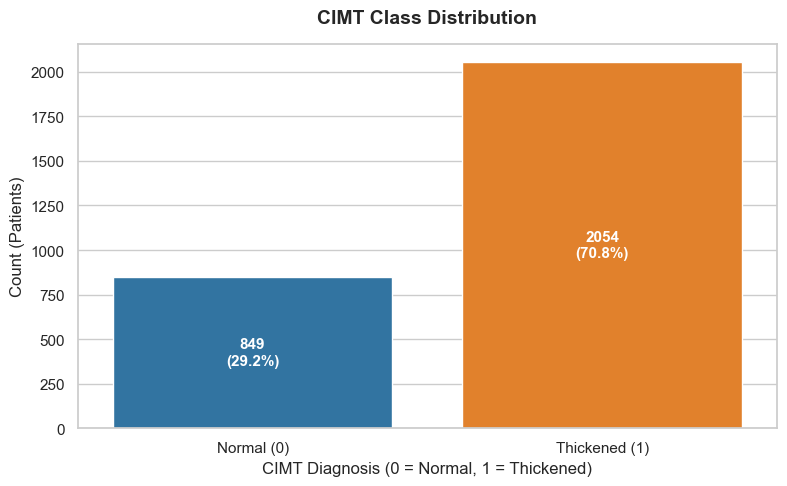

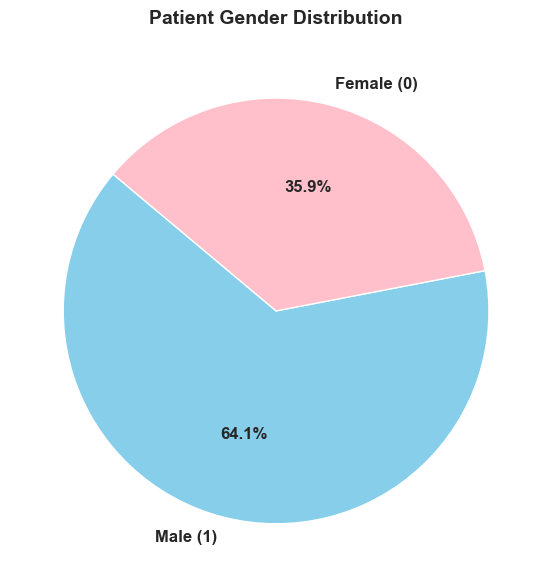

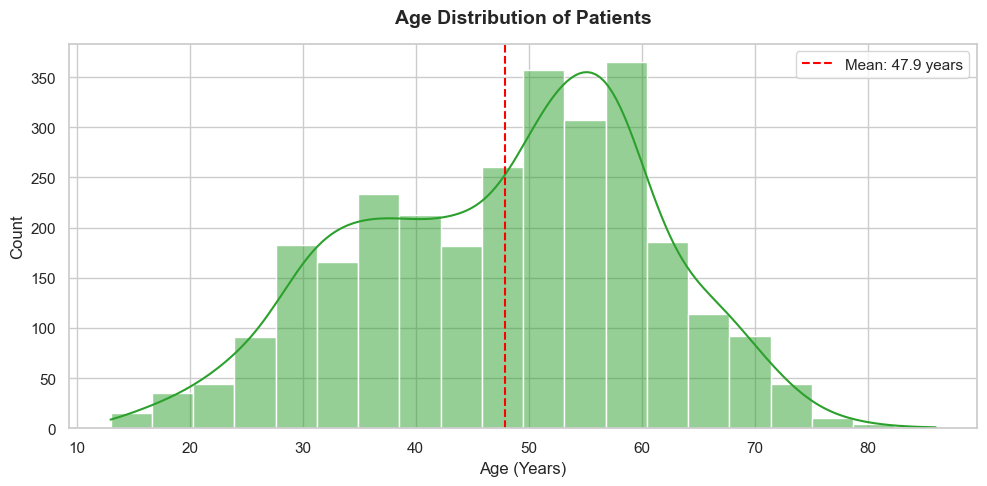

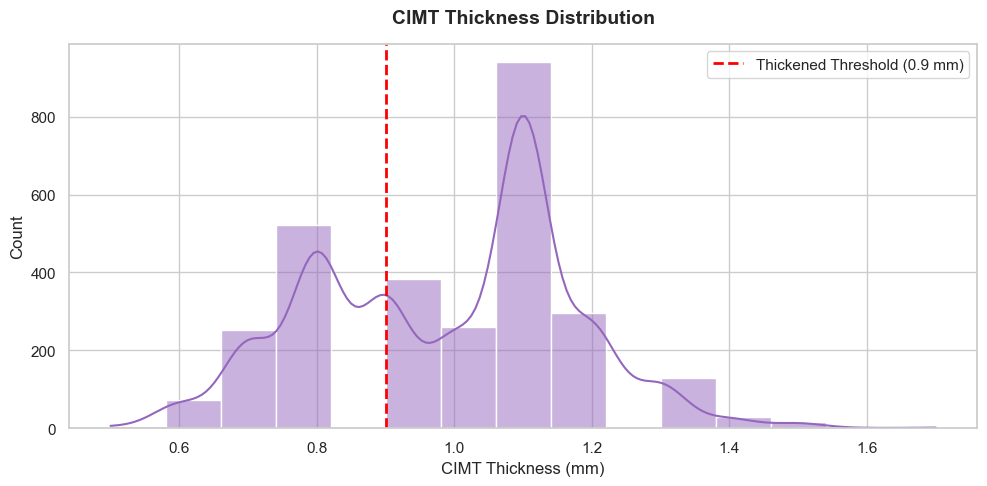

In [5]:
# ============================================================
# BLOCK 5: GENERATE & SAVE DISTRIBUTION PLOTS
# ============================================================
# 1. Class Distribution Bar Chart
plt.figure(figsize=(8, 5))
colors = ['#1f77b4', '#ff7f0e']
ax = sns.countplot(data=df, x='label', palette=colors)
plt.title('CIMT Class Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('CIMT Diagnosis (0 = Normal, 1 = Thickened)', fontsize=12)
plt.ylabel('Count (Patients)', fontsize=12)
ax.set_xticklabels(['Normal (0)', 'Thickened (1)'])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}\n({p.get_height()/total_patients*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2.),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'class_distribution.png'), dpi=300)
plt.show()
plt.close()

# 2. Gender Distribution Pie Chart
plt.figure(figsize=(6, 6))
gender_data = [gender_counts.get(1, 0), gender_counts.get(0, 0)]
labels = ['Male (1)', 'Female (0)']
colors = ['#87ceeb', '#ffc0cb']
plt.pie(gender_data, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, 
        textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Patient Gender Distribution', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'gender_distribution.png'), dpi=300)
plt.show()
plt.close()

# 3. Age Distribution Histogram
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', bins=20, kde=True, color='#2ca02c')
plt.title('Age Distribution of Patients', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['age'].mean():.1f} years")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'age_distribution.png'), dpi=300)
plt.show()
plt.close()

# 4. CIMT Thickness Distribution Histogram
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='thickness', bins=15, kde=True, color='#9467bd')
plt.title('CIMT Thickness Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('CIMT Thickness (mm)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(x=0.9, color='red', linestyle='--', linewidth=2.0, label='Thickened Threshold (0.9 mm)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cimt_thickness_distribution.png'), dpi=300)
plt.show()
plt.close()

## Data Quality Check
We check if referenced image files exist, get image shapes, and catch corrupted files using Try-Except Pillow loading checks.

In [6]:
# ============================================================
# BLOCK 6: DATA QUALITY CHECK
# ============================================================
missing_files = []
corrupted_files = []
dimensions = []

for idx, row in df.iterrows():
    l_img = row['left_eye']
    r_img = row['right_eye']
    
    for img_name in [l_img, r_img]:
        if not img_name:
            continue
        image_path = os.path.join(IMAGES_DIR, img_name)
        
        # Check if file exists
        if not os.path.exists(image_path):
            missing_files.append(img_name)
            continue
        
        # Check for corruption and get properties
        try:
            with Image.open(image_path) as img:
                img.verify()  # Check file structure integrity
            # Re-open to load actual data
            with Image.open(image_path) as img2:
                width, height = img2.size
                channels = len(img2.getbands())
                dimensions.append((width, height, channels))
        except Exception as e:
            corrupted_files.append((img_name, str(e)))

total_found = total_images - len(missing_files)

print("="*60)
print("DATA QUALITY CHECK RESULTS")
print("="*60)
print(f"Total Referenced Images:   {total_images}")
print(f"Successfully Found Images: {total_found}")
print(f"Missing Images:            {len(missing_files)} ({len(missing_files)/total_images*100:.2f}%)")
print(f"Corrupted Images:          {len(corrupted_files)}")

if len(dimensions) > 0:
    widths, heights, channels_list = zip(*dimensions)
    print(f"Image Resolution (Widths):  Min {min(widths)}, Max {max(widths)}")
    print(f"Image Resolution (Heights): Min {min(heights)}, Max {max(heights)}")
    print(f"Unique Channels Detected:   {set(channels_list)}")
print("="*60)

DATA QUALITY CHECK RESULTS
Total Referenced Images:   5806
Successfully Found Images: 5806
Missing Images:            0 (0.00%)
Corrupted Images:          0
Image Resolution (Widths):  Min 512, Max 512
Image Resolution (Heights): Min 512, Max 512
Unique Channels Detected:   {3}


## Display Sample Images Grid
We select 8 sample patient eye images (4 normal, 4 thickened) dynamically (with fallback), plot them in a grid, and save the grid to disk.

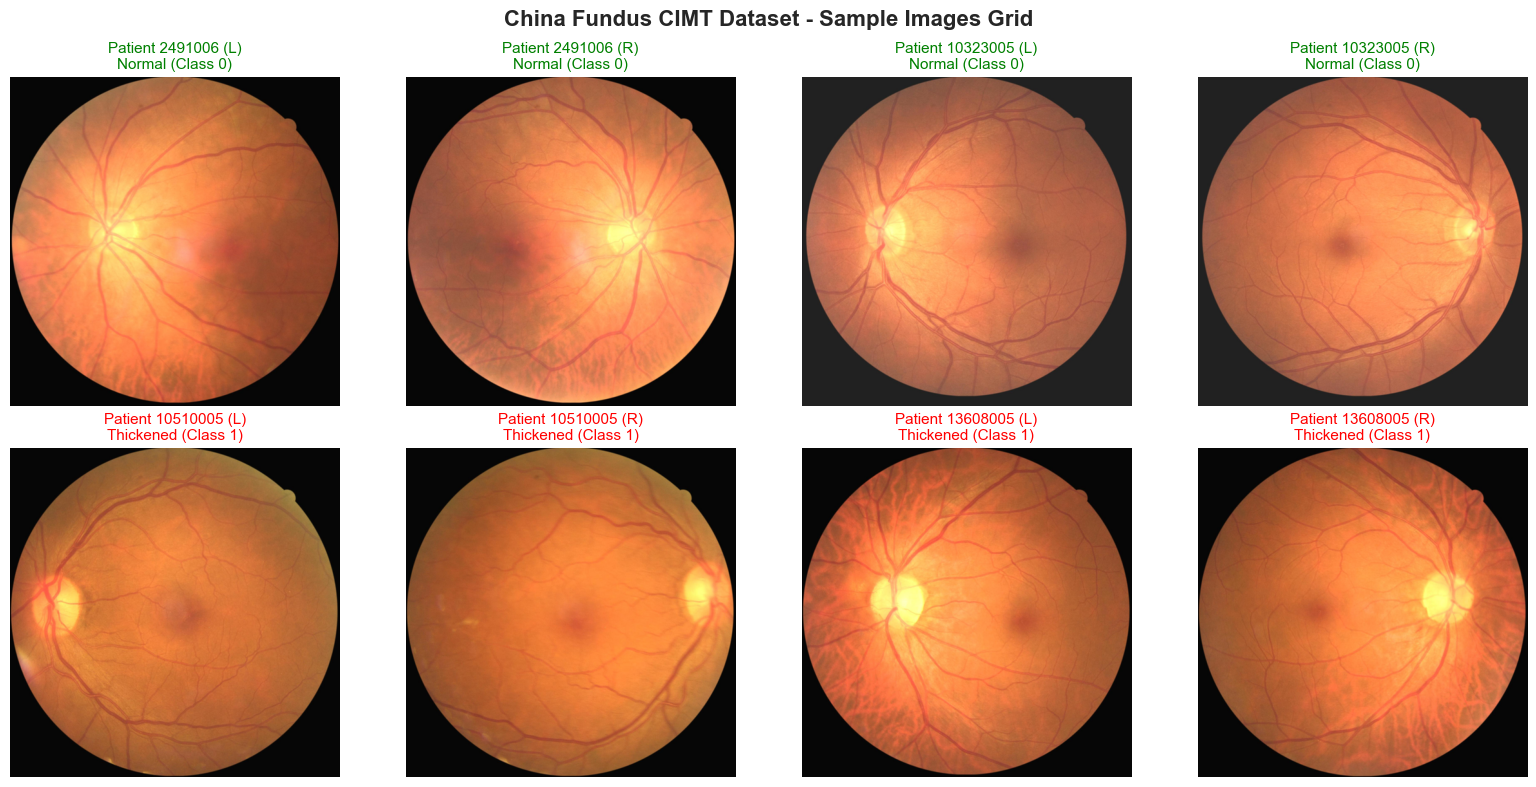

In [7]:
# ============================================================
# BLOCK 7: SAMPLE IMAGES GRID
# ============================================================
# Target sample candidates present locally
normal_candidates = ['2491006', '10323005', '11036005', '11777005']
thickened_candidates = ['10510005', '13608005', '14801005', '16669003']

def select_samples(label_val, candidates):
    selected = []
    # Try hardcoded candidates first
    for pid in candidates:
        if pid in df['patient_id'].values:
            p_info = df[df['patient_id'] == pid].iloc[0]
            l_path = os.path.join(IMAGES_DIR, p_info['left_eye'])
            r_path = os.path.join(IMAGES_DIR, p_info['right_eye'])
            if os.path.exists(l_path) and os.path.exists(r_path):
                selected.append((pid, p_info['left_eye'], p_info['right_eye']))
                if len(selected) == 2:
                    break
                    
    # Fallback to dynamic selection if needed
    if len(selected) < 2:
        for idx, row in df[df['label'] == label_val].iterrows():
            pid = row['patient_id']
            if pid in [s[0] for s in selected]:
                continue
            l_path = os.path.join(IMAGES_DIR, row['left_eye'])
            r_path = os.path.join(IMAGES_DIR, row['right_eye'])
            if os.path.exists(l_path) and os.path.exists(r_path):
                selected.append((pid, row['left_eye'], row['right_eye']))
                if len(selected) == 2:
                    break
    return selected

normal_samples = select_samples(0, normal_candidates)
thickened_samples = select_samples(1, thickened_candidates)

# Grid structure: 2 rows (Normal and Thickened), 4 columns (2 patients, L/R eyes)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Row 0: Normal Patients
for col_idx, (pid, l_file, r_file) in enumerate(normal_samples):
    l_img = Image.open(os.path.join(IMAGES_DIR, l_file))
    r_img = Image.open(os.path.join(IMAGES_DIR, r_file))
    
    # Left eye
    axes[0, col_idx*2].imshow(l_img)
    axes[0, col_idx*2].set_title(f"Patient {pid} (L)\nNormal (Class 0)", fontsize=11, color='green')
    axes[0, col_idx*2].axis('off')
    
    # Right eye
    axes[0, col_idx*2+1].imshow(r_img)
    axes[0, col_idx*2+1].set_title(f"Patient {pid} (R)\nNormal (Class 0)", fontsize=11, color='green')
    axes[0, col_idx*2+1].axis('off')

# Row 1: Thickened Patients
for col_idx, (pid, l_file, r_file) in enumerate(thickened_samples):
    l_img = Image.open(os.path.join(IMAGES_DIR, l_file))
    r_img = Image.open(os.path.join(IMAGES_DIR, r_file))
    
    # Left eye
    axes[1, col_idx*2].imshow(l_img)
    axes[1, col_idx*2].set_title(f"Patient {pid} (L)\nThickened (Class 1)", fontsize=11, color='red')
    axes[1, col_idx*2].axis('off')
    
    # Right eye
    axes[1, col_idx*2+1].imshow(r_img)
    axes[1, col_idx*2+1].set_title(f"Patient {pid} (R)\nThickened (Class 1)", fontsize=11, color='red')
    axes[1, col_idx*2+1].axis('off')

plt.suptitle("China Fundus CIMT Dataset - Sample Images Grid", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'sample_images_grid.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Summary Statistics Printout
Finally, we print a comprehensive final text summary of the dataset.

In [8]:
# ============================================================
# BLOCK 8: FINAL SUMMARY STATISTICS
# ============================================================
print("="*60)
print("FINAL SUMMARY STATISTICS: CHINA FUNDUS CIMT DATASET")
print("="*60)
print(f"Total Patients:           {total_patients}")
print(f"Total Referenced Images:  {total_images} (both eyes)")
print(f"Class 0 (Normal):         {class_counts.get(0, 0)} patients ({class_pcts.get(0, 0.0):.2f}%)")
print(f"Class 1 (Thickened):      {class_counts.get(1, 0)} patients ({class_pcts.get(1, 0.0):.2f}%)")
print(f"Gender Distribution:      Male: {gender_counts.get(1, 0)} ({gender_counts.get(1, 0)/total_patients*100:.2f}%), "
      f"Female: {gender_counts.get(0, 0)} ({gender_counts.get(0, 0)/total_patients*100:.2f}%)")
print(f"Age range:                {age_min} to {age_max} years (Mean: {df['age'].mean():.1f} years)")
print(f"CIMT Thickness range:     {thickness_min:.2f} to {thickness_max:.2f} mm (Mean: {df['thickness'].mean():.2f} mm)")
print(f"Missing Images:           {len(missing_files)} ({len(missing_files)/total_images*100:.2f}%)")
print(f"Corrupted Images:         {len(corrupted_files)}")
print("="*60)

FINAL SUMMARY STATISTICS: CHINA FUNDUS CIMT DATASET
Total Patients:           2903
Total Referenced Images:  5806 (both eyes)
Class 0 (Normal):         849 patients (29.25%)
Class 1 (Thickened):      2054 patients (70.75%)
Gender Distribution:      Male: 1862 (64.14%), Female: 1041 (35.86%)
Age range:                13 to 86 years (Mean: 47.9 years)
CIMT Thickness range:     0.50 to 1.70 mm (Mean: 0.99 mm)
Missing Images:           0 (0.00%)
Corrupted Images:         0
